In [5]:
import openmeteo_requests
import requests_cache
import pandas as pd 
from retry_requests import retry

In [8]:
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

params = {
    'latitude': 52.37,
    'longitude': 4.89,
    'start_date': "2020-08-10",
    'end_date': "2024-08-23",
    'hourly': "temperature_2m",
    'daily': "temperature_2m_mean",
    'timezone': "Europe/Amsterdam"   
}
responses = openmeteo.weather_api(url, params=params)

In [10]:
response = responses[0]
print(f"Elevation = {response.Elevation()} metres ")
print(f"Timezone {response.Timezone().decode()} {response.TimezoneAbbreviation().decode()} ")
print(f"Time Zone difference to GMT is {response.UtcOffsetSeconds()} seconds")

Elevation = 11.0 metres 
Timezone Europe/Amsterdam GMT+2 
Time Zone difference to GMT is 7200 seconds


In [24]:
daily = response.Daily()
daily_temperature = daily.Variables(0).ValuesAsNumpy()

In [25]:
daily_data = {'data': pd.date_range(start=pd.to_datetime(daily.Time(), unit='s', utc= True),
                                     end = pd.to_datetime(daily.TimeEnd(), unit='s', utc= True),
                                     freq = pd.Timedelta(seconds=daily.Interval()),
                                     inclusive = 'left')}
daily_data['temperature_2m'] = daily_temperature

In [26]:
daily_dataframe = pd.DataFrame(data = daily_data)
print(daily_dataframe.head(15))
print(daily_dataframe.isna().sum())
print(len(daily_dataframe))

                        data  temperature_2m
0  2020-08-09 22:00:00+00:00             NaN
1  2020-08-10 22:00:00+00:00             NaN
2  2020-08-11 22:00:00+00:00             NaN
3  2020-08-12 22:00:00+00:00             NaN
4  2020-08-13 22:00:00+00:00             NaN
5  2020-08-14 22:00:00+00:00             NaN
6  2020-08-15 22:00:00+00:00             NaN
7  2020-08-16 22:00:00+00:00             NaN
8  2020-08-17 22:00:00+00:00             NaN
9  2020-08-18 22:00:00+00:00             NaN
10 2020-08-19 22:00:00+00:00             NaN
11 2020-08-20 22:00:00+00:00             NaN
12 2020-08-21 22:00:00+00:00             NaN
13 2020-08-22 22:00:00+00:00             NaN
14 2020-08-23 22:00:00+00:00             NaN
data                0
temperature_2m    226
dtype: int64
1475


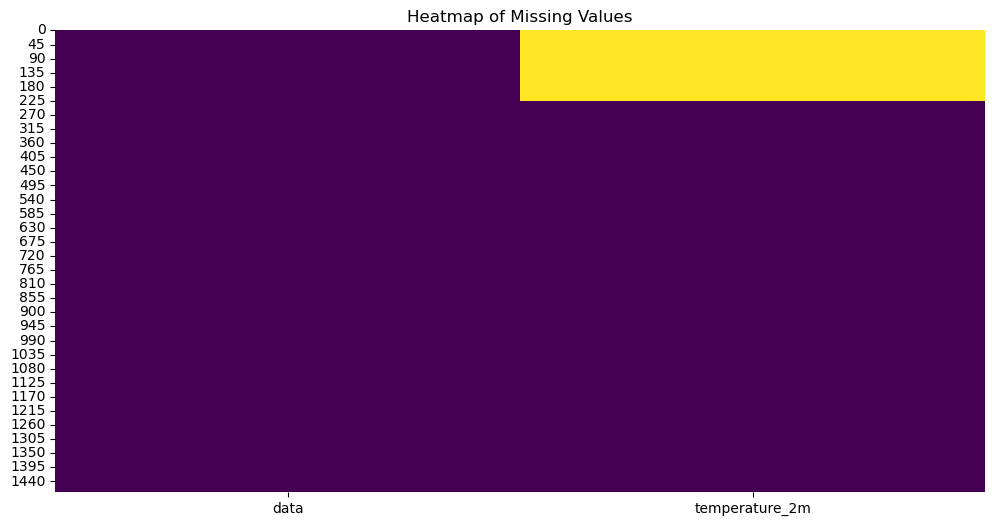

In [33]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(daily_dataframe.isna(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Assume df has a datetime index and a 'temp' column

# Step 1: Create day index
df = df.copy()
df['day'] = np.arange(len(df))

# Step 2: Split known and unknown
df_known = df.iloc[226:]      # known values
df_missing = df.iloc[:226]    # NaNs

# Step 3: Train regression model
X_train = df_known[['day']]
y_train = df_known['temp']
model = LinearRegression().fit(X_train, y_train)

# Step 4: Predict missing values
X_pred = df_missing[['day']]
df.loc[:225, 'temp'] = model.predict(X_pred)
